In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# STUDENTS: IGNORE THIS CELL ON YOUR FIRST READ-THROUGH
# (It contains helper functions that you'll use below)
# ==========================================================
def make_disk_centers(R=1.0, spacing=0.06):
    """
    Make atom centers on a square grid, then keep only the ones inside a disk.
    Returns an (N, 2) array of (x, y) positions.
    """
    xs = np.arange(-R, R + spacing, spacing)
    ys = np.arange(-R, R + spacing, spacing)
    X, Y = np.meshgrid(xs, ys)

    centers = np.column_stack([X.ravel(), Y.ravel()])
    r = np.hypot(centers[:, 0], centers[:, 1])

    return centers[r <= R]


def dipole_charges_from_centers(centers, delta=0.12, direction=(1.0, 0.0)):
    """
    For each atom center, place a +1 and -1 charge separated by distance delta
    along the given direction.
    Returns:
      charges_pos: (2N, 2) positions of all charges
      charges_q:   (2N,)   charge values (+1 or -1)
    """
    u = np.array(direction, dtype=float)
    u = u / np.linalg.norm(u)     # unit vector in polarization direction

    shift = 0.5 * delta * u       # half-separation
    pos_plus  = centers + shift
    pos_minus = centers - shift

    charges_pos = np.vstack([pos_plus, pos_minus])
    charges_q   = np.hstack([np.ones(len(centers)), -np.ones(len(centers))])

    return charges_pos, charges_q


def t_on_disk_boundary(x, y):
    """
    Map (x,y) angle to t in [0,1), clockwise from 12 o'clock.
    t=0 at (0, +R), t increases clockwise.
    """
    theta = np.arctan2(y, x)  # [-pi, pi], theta=0 on +x axis (3 o'clock), CCW positive
    t = np.mod((np.pi/2 - theta), 2*np.pi) / (2*np.pi)
    return t


def count_charge_by_t_disk(charges_pos, charges_q, R=1.0, shell_thickness=0.08, nbins=60):
    """
    Approximate surface bound charge by:
      1) keeping only charges in a thin shell near the disk boundary
      2) converting their positions to perimeter parameter t
      3) binning net charge by t
    """
    x, y = charges_pos[:, 0], charges_pos[:, 1]
    r = np.hypot(x, y)

    # Keep only charges near the boundary (a stand-in for 'surface')
    mask = (r >= R - shell_thickness)
    x_s, y_s, q_s = x[mask], y[mask], charges_q[mask]

    t_s = t_on_disk_boundary(x_s, y_s)

    edges = np.linspace(0.0, 1.0, nbins + 1)
    q_t = np.zeros(nbins)
    for i in range(nbins):
        inbin = (t_s >= edges[i]) & (t_s < edges[i+1])
        q_t[i] = q_s[inbin].sum()

    t_centers = 0.5*(edges[:-1] + edges[1:])
    return t_centers, q_t

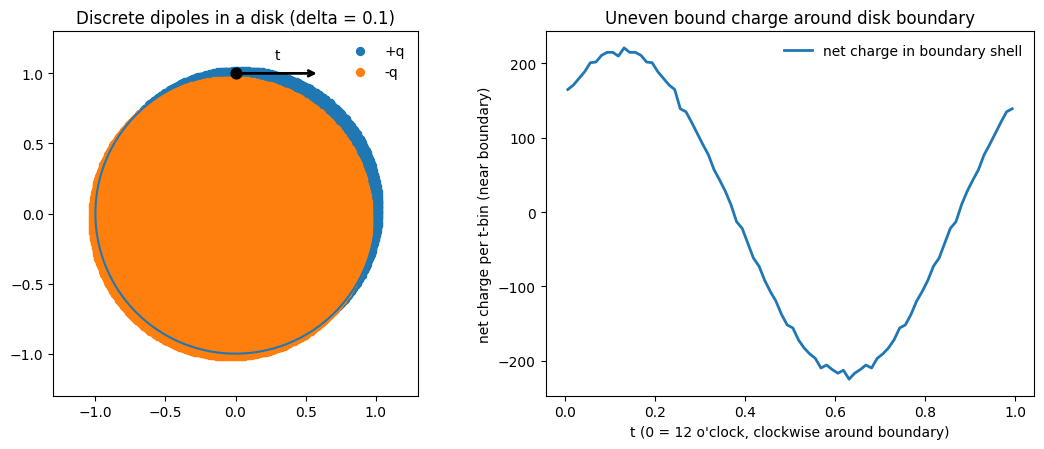

In [8]:
# ==========================================================
# STUDENTS: READ THIS CELL TOP-TO-BOTTOM
# Re-run after changing parameters on lines 9-16
# We measure "surface charge" by walking around the boundary
# using a perimeter parameter t (clockwise from 12 o'clock).
# ==========================================================

# 1) Choose parameters (delta is the main knob!)
R = 1.0                 # radius of disk
spacing = 0.006          # how dense the atoms are

delta = 0.1             # <-- polarization strength: how far each atom is "stretched"
direction = (1.0, 01.0)  # polarization direction (try (1,0), then (0,1), then (1,1))

shell_thickness = 0.08  # thickness of the "surface region" we use to measure bound charge
nbins = 80             # how many bins around the boundary

# 2) Build the dielectric as many atom centers filling a disk
centers = make_disk_centers(R=R, spacing=spacing)

# 3) "Stretch every atom" by turning each one into a tiny dipole (+ and - separated by delta)
charges_pos, charges_q = dipole_charges_from_centers(
    centers,
    delta=delta,
    direction=direction
)

# 4) Estimate bound surface charge by binning near-boundary charge vs t in [0,1)
t_centers, q_t = count_charge_by_t_disk(
    charges_pos, charges_q,
    R=R,
    shell_thickness=shell_thickness,
    nbins=nbins
)

# 5) Plot results:
#    (left) the charges in the disk + t=0 marker and arrow showing +t direction
#    (right) net "surface" charge vs t
fig = plt.figure(figsize=(11, 4.6))

# ---- Left plot: charges in the disk ----
ax1 = fig.add_subplot(1, 2, 1)

# draw disk boundary
ang = np.linspace(0, 2*np.pi, 400)
ax1.plot(R*np.cos(ang), R*np.sin(ang))

plus = charges_q > 0
minus = charges_q < 0

ax1.scatter(charges_pos[plus, 0],  charges_pos[plus, 1],  s=8, label="+q")
ax1.scatter(charges_pos[minus, 0], charges_pos[minus, 1], s=8, label="-q")

# --- Mark t = 0 at 12 o'clock (0, +R) ---
t0_x, t0_y = 0.0, R
ax1.scatter([t0_x], [t0_y], s=60, zorder=5, color="black")

# --- Arrow showing direction of increasing t (clockwise) ---
# At 12 o'clock, clockwise direction points to the right.
arrow_len = 0.6 * R
ax1.annotate(
    "", xy=(t0_x + arrow_len, t0_y), xytext=(t0_x, t0_y),
    arrowprops=dict(arrowstyle="->", linewidth=2),
)
ax1.text(t0_x + 0.5*arrow_len, t0_y + 0.08*R, "t", ha="center", va="bottom")

ax1.set_aspect("equal", "box")
ax1.set_xlim(-1.3*R, 1.3*R)
ax1.set_ylim(-1.3*R, 1.3*R)
ax1.set_title(f"Discrete dipoles in a disk (delta = {delta})")
ax1.legend(loc="upper right", frameon=False, markerscale=2)

# ---- Right plot: net charge vs t ----
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t_centers, q_t, linewidth=2, label="net charge in boundary shell")

ax2.set_xlabel("t (0 = 12 o'clock, clockwise around boundary)")
ax2.set_ylabel("net charge per t-bin (near boundary)")
ax2.set_title("Uneven bound charge around disk boundary")
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()